# `define_train_test_split`

## Purpose

Find date/site split points for training, validation, and testing sets with the goal of roughly a 60/20/20% split into train/val/test.

## Previous notebook

`aki_calc_covariates_and_modeling`

## Next notebook

`single_feature_model_performance`

# Imports

In [1]:
import pandas as pd
import numpy
from statistics import median
import os, sys, importlib, gc
import pickle

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Ignore warnings from pandas
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
from set_env_vars import set_all_env_vars

set_all_env_vars()

# Load data

In [4]:
cohort = pd.read_csv(os.getenv('AKI_DATA_PDC') + 'final_aki_cohort.csv')

cohort = cohort[cohort['new_aki'] != 'On Admit']

# Load admissions data to get year of admission by encounter

In [7]:
import azureml.fsspec

uri = 'URI_GOES_HERE'

h_lim = pd.read_csv(
    uri + 'hospitaladmissions.csv'
)

Resolving access token for scope "https://storage.azure.com/.default" using identity of type "MANAGED".
Getting data access token with Assigned Identity (client_id=clientid) and endpoint type based on configuration


In [9]:
cohort = cohort.merge(
    h_lim,
    on=["pdc_hid", "pdc_pid", "site_id"],
    how='left'
)

# Compare number of unique encounters by site and year

## Create a composite hashid for grouping purposes

In [10]:
cohort['enc_hashid'] = cohort['pdc_eid'].astype(str) + cohort['pdc_hid'].astype(str) + cohort['pdc_pid'].astype(str)

## Find number/proportion of unique encounters from each site

[Text(0.5, 0, 'Site'),
 Text(0, 0.5, 'Proportion of Encounters'),
 Text(0.5, 1.0, 'Proportion of Unique Encounters By Site')]

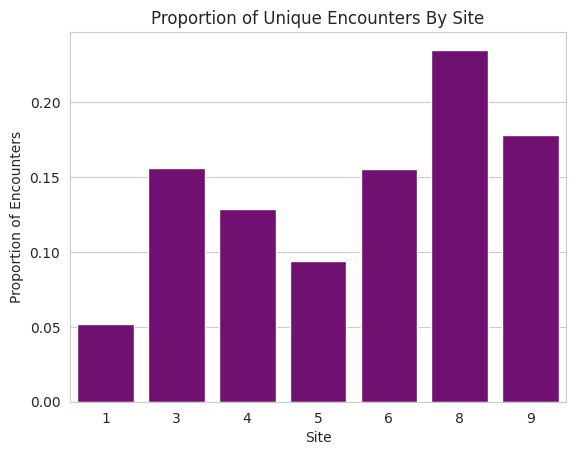

In [11]:
enc_by_site_counts = cohort[[
    'enc_hashid', 'site_id'
]] \
.groupby('site_id') \
.count() \
.reset_index() \
.rename(
    columns={'enc_hashid': 'enc_count'}
)

enc_by_site_counts['enc_prop'] = enc_by_site_counts['enc_count'] / enc_by_site_counts['enc_count'].sum()

sns.barplot(
    enc_by_site_counts,
    x='site_id',
    y='enc_prop',
    color='purple'
) \
.set(
    xlabel='Site',
    ylabel='Proportion of Encounters',
    title='Proportion of Unique Encounters By Site'
)

## Find number/proportions of unique hospital admissions by year

[Text(0.5, 0, 'Year of Admission'),
 Text(0, 0.5, 'Proportion of Encounters'),
 Text(0.5, 1.0, 'Proportion of Unique Encounters By Year of Admission')]

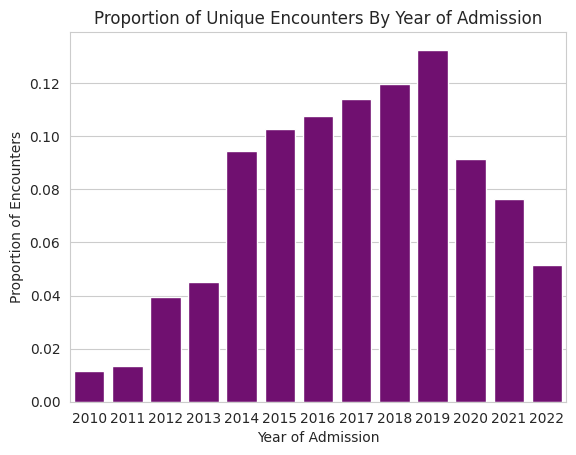

In [12]:
enc_by_year_counts = cohort[[
    'enc_hashid', 'yearofadmission'
]] \
.groupby('yearofadmission') \
.count() \
.reset_index() \
.rename(
    columns={'enc_hashid': 'enc_count'}
)

enc_by_year_counts['enc_prop'] = enc_by_year_counts['enc_count'] / enc_by_year_counts['enc_count'].sum()

sns.barplot(
    enc_by_year_counts,
    x='yearofadmission',
    y='enc_prop',
    color='purple'
) \
.set(
    xlabel='Year of Admission',
    ylabel='Proportion of Encounters',
    title='Proportion of Unique Encounters By Year of Admission'
)

In [13]:
enc_by_year_counts

,yearofadmission,enc_count,enc_prop
0,2010,1493,0.011421
1,2011,1775,0.013578
2,2012,5171,0.039557
3,2013,5890,0.045057
4,2014,12323,0.094267
5,2015,13411,0.102590
6,2016,14065,0.107593
7,2017,14928,0.114195
8,2018,15665,0.119833
9,2019,17335,0.132608


In [85]:
len(cohort[cohort['yearofadmission'].isin([2021, 2022]) | (cohort['site_id']==5)])

26758

In [86]:
len(cohort[cohort['yearofadmission'].isin([2021, 2022]) | (cohort['site_id']==5)]) / len(cohort)

0.2046907989351611

Number of encounters from 2021 or 2022 at site 5:

In [87]:
len(cohort[cohort['yearofadmission'].isin([2021, 2022]) & (cohort['site_id']==5)])

2259

Number of encounters from 2021 or 2022 in any site:

In [88]:
len(cohort[cohort['yearofadmission'].isin([2021, 2022])])

16696

Number of encounters at site 5 in any year:

In [89]:
len(cohort[(cohort['site_id']==5)])

12321

## Save identifiers for test set to CSV

In [90]:
test_set_ids = cohort[
    cohort['yearofadmission'].isin([2021, 2022]) | (cohort['site_id']==5)
][[
    'pdc_pid',
    'pdc_hid',
    'pdc_eid',
    'n_icuadmit',
    'site_id'
]]

test_set_ids.to_csv(os.getenv('AKI_DATA_PDC') + 'test_set_identifiers.csv', index=False)

# Split development set into train/validation sets

In [1]:
dev_set_ids = base_cohort[
    (~base_cohort['yearofadmission'].isin([2021, 2022])) & (base_cohort['site_id']!=5)
][[
    'pdc_pid',
    'pdc_hid',
    'pdc_eid',
    'site_id'
]]

In [96]:
dev_cohort = dev_set_ids.merge(
    cohort,
    on=['pdc_pid', 'pdc_hid', 'pdc_eid', 'site_id'],
    how='inner'
)

[Text(0.5, 0, 'Year of Admission'),
 Text(0, 0.5, 'Proportion of Encounters in Dev Set'),
 Text(0.5, 1.0, 'Proportion of Encounters in Dev Set By Year of Admission')]

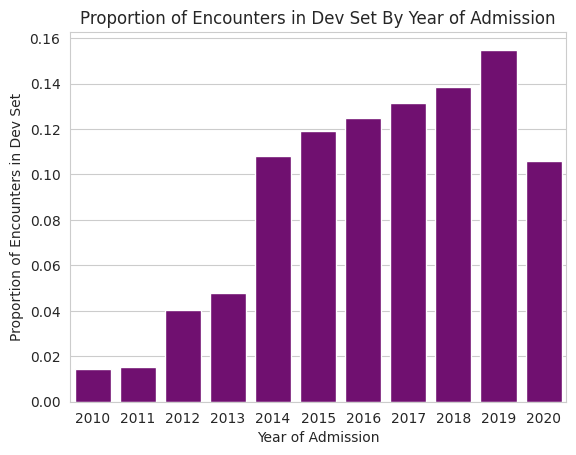

In [98]:
dev_enc_counts_by_year = dev_cohort[[
    'enc_hashid', 'yearofadmission'
]] \
.groupby('yearofadmission') \
.count() \
.reset_index() \
.rename(columns={'enc_hashid': 'enc_count'})

dev_enc_counts_by_year['enc_prop'] = dev_enc_counts_by_year['enc_count'] / dev_enc_counts_by_year['enc_count'].sum()

sns.barplot(
    dev_enc_counts_by_year,
    x='yearofadmission',
    y='enc_prop',
    color='purple'
) \
.set(
    xlabel='Year of Admission',
    ylabel='Proportion of Encounters in Dev Set',
    title='Proportion of Encounters in Dev Set By Year of Admission'
)

In [99]:
len(dev_cohort[dev_cohort['yearofadmission'] > 2018]) / len(dev_cohort)

0.26093470869590274

[Text(0.5, 0, 'Site'),
 Text(0, 0.5, 'Proportion of Encounters in Dev Set'),
 Text(0.5, 1.0, 'Proportion of Encounters in Dev Set By Site')]

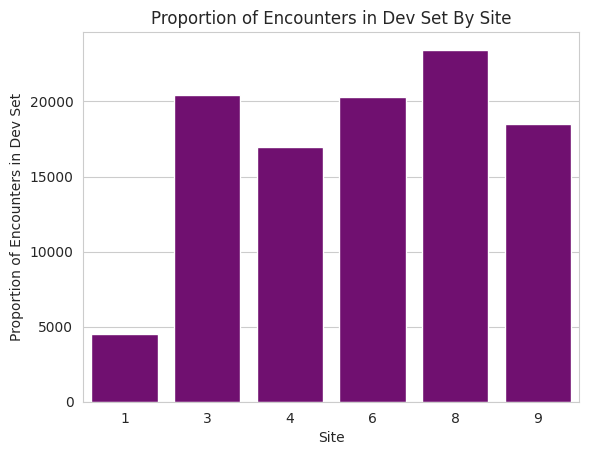

In [100]:
dev_enc_counts_by_site = dev_cohort[[
    'enc_hashid', 'site_id'
]] \
.groupby('site_id') \
.count() \
.reset_index() \
.rename(columns={'enc_hashid': 'enc_count'})

dev_enc_counts_by_year['enc_prop'] = dev_enc_counts_by_year['enc_count'] / dev_enc_counts_by_year['enc_count'].sum()

sns.barplot(
    dev_enc_counts_by_site,
    x='site_id',
    y='enc_count',
    color='purple'
) \
.set(
    xlabel='Site',
    ylabel='Proportion of Encounters in Dev Set',
    title='Proportion of Encounters in Dev Set By Site'
)

We get a validation set of close to 25% of the size of the dev set if we split by defining the train set as all encounters with admissions prior to 2019 and the validation set as everything after, so let's do that:

In [101]:
train_cohort = dev_cohort[dev_cohort['yearofadmission'] < 2019]
val_cohort = dev_cohort[dev_cohort['yearofadmission'] >= 2019]

In [102]:
train_cohort[[
    'pdc_pid',
    'pdc_hid',
    'pdc_eid',
    'n_icuadmit',
    'site_id'
]] \
.drop_duplicates() \
.to_csv(os.getenv('AKI_DATA_PDC') + 'train_set_identifiers.csv', index=False)

val_cohort[[
    'pdc_pid',
    'pdc_hid',
    'pdc_eid',
    'n_icuadmit',
    'site_id'
]] \
.drop_duplicates() \
.to_csv(os.getenv('AKI_DATA_PDC') + 'val_set_identifiers.csv', index=False)

In [6]:
train_set_ids = pd.read_csv(os.getenv('AKI_DATA_PDC') + 'train_set_identifiers.csv')
val_set_ids = pd.read_csv(os.getenv('AKI_DATA_PDC') + 'val_set_identifiers.csv')
test_set_ids = pd.read_csv(os.getenv('AKI_DATA_PDC') + 'test_set_identifiers.csv')

In [8]:
train_size = len(train_set_ids)
val_size = len(val_set_ids)
test_size = len(test_set_ids)
total_size = train_size + val_size + test_size

print('Train cohort size = %d (%.2f)' % (train_size, (train_size / total_size)))
print('Val cohort size = %d (%.2f)' % (val_size, (val_size / total_size)))
print('Test cohort size = %d (%.2f)' % (test_size, (test_size / total_size)))

Train cohort size = 76822 (0.59)
Val cohort size = 27144 (0.21)
Test cohort size = 26758 (0.20)
